# Partie 4 - BD vectorielle et embeddings

**Objectif :** lire un article au format Word (`.docx`) et déterminer s’il s’agit d’un article de **sport**, de **cuisine**, ou d’un article **ambigu** lorsque le texte mélange les deux thèmes.

Pour réaliser cette classification, le programme utilise une approche basée sur les embeddings et une base vectorielle FAISS. Chaque article est transformé en vecteur numérique. Les documents de test sont ensuite comparés aux documents d’entraînement afin d’identifier les articles les plus proches.

Méthode utilisée :

1. lire les documents Word ;
2. nettoyer et tokeniser le texte en ignorant la ponctuation ;
3. générer les embeddings avec `sentence-transformers` ;
4. stocker les embeddings des documents d’entraînement dans FAISS ;
5. classer un nouvel article à partir de ses plus proches voisins ;
6. détecter les cas ambigus lorsque la prédiction n’est pas suffisamment fiable.

Les fichiers d’entraînement servent de base de référence pour les catégories sport et cuisine. Les fichiers de test sont utilisés séparément afin d’évaluer les prédictions du programme sur de nouveaux articles.

## 1. Installation des bibliothèques

À exécuter une seule fois si les bibliothèques ne sont pas encore installées.

In [17]:
%pip install python-docx sentence-transformers faiss-cpu numpy pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Imports et configuration

In [33]:
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import faiss
from docx import Document
from sentence_transformers import SentenceTransformer

# Affichage
pd.set_option("display.max_colwidth", 120)

# Lancer depuis la racine du projet ou depuis le dossier notebook/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_TRAIN_DIR = PROJECT_ROOT / "data" / "train"
DATA_TEST_DIR = PROJECT_ROOT / "data" / "test"

print("Racine du projet :", PROJECT_ROOT)
print("Dossier train :", DATA_TRAIN_DIR)
print("Dossier test :", DATA_TEST_DIR)

Racine du projet : c:\Users\bouck\OneDrive - Haute Ecole de Namur-Liege-Luxembourg\Documents\CoursHenallux\MachineLearning\titanic\Travail Machine Learning Part2\Part4 - BD vectorielle_Embeddings
Dossier train : c:\Users\bouck\OneDrive - Haute Ecole de Namur-Liege-Luxembourg\Documents\CoursHenallux\MachineLearning\titanic\Travail Machine Learning Part2\Part4 - BD vectorielle_Embeddings\data\train
Dossier test : c:\Users\bouck\OneDrive - Haute Ecole de Namur-Liege-Luxembourg\Documents\CoursHenallux\MachineLearning\titanic\Travail Machine Learning Part2\Part4 - BD vectorielle_Embeddings\data\test


## 3. Lecture des fichiers Word

La fonction suivante lit tous les paragraphes non vides d'un document `.docx`.

In [34]:
def lire_docx(chemin_fichier: Path) -> str:
    """
    Lit un fichier Word .docx et retourne son contenu sous forme de texte.
    """
    document = Document(str(chemin_fichier))
    paragraphes = [p.text.strip() for p in document.paragraphs if p.text.strip()]
    return "\n".join(paragraphes)

# Exemple de lecture
exemple_fichier = sorted(DATA_TRAIN_DIR.glob("*.docx"))[0]
print("Fichier lu :", exemple_fichier.name)
print(lire_docx(exemple_fichier)[:500])

Fichier lu : cuisine_boulangerie.docx
Pain artisanal en boulangerie
La fabrication d'un pain artisanal commence par le mélange de la farine, de l'eau, du levain et du sel. Le boulanger pétrit la pâte jusqu'à obtenir une texture souple, puis la laisse fermenter pour développer les arômes et améliorer la structure de la mie.
Le façonnage permet de donner au pain sa forme définitive avant une deuxième période de repos. Juste avant l'enfournement, la surface est incisée pour contrôler l'ouverture de la croûte pendant la cuisson dans un 


## 4. Tokenisation sans ponctuation

Pour tokeniser le document en ignorant la ponctuation, on met le texte en minuscules, puis on garde uniquement les suites de lettres, y compris les lettres accentuées.

In [35]:
def tokenizer_sans_ponctuation(texte: str) -> list[str]:
    """
    Tokenise un texte en ignorant la ponctuation.
    La regex garde les mots composés de lettres, y compris les accents français.
    """
    texte = texte.lower()
    tokens = re.findall(r"[a-zàâçéèêëîïôûùüÿñæœ]+", texte)
    return tokens


def nettoyer_texte(texte: str) -> str:
    """
    Nettoie le texte : suppression de la ponctuation puis reconstruction d'une chaîne.
    """
    tokens = tokenizer_sans_ponctuation(texte)
    return " ".join(tokens)

# Démonstration rapide
phrase = "Le match, très intense, s'est terminé à 2-1 !"
print(tokenizer_sans_ponctuation(phrase))

['le', 'match', 'très', 'intense', 's', 'est', 'terminé', 'à']


## 5. Chargement du jeu d'entraînement

Les fichiers d'entraînement sont nommés avec un préfixe :

- `sport_...docx` pour les articles de sport ;
- `cuisine_...docx` pour les articles de cuisine.

In [36]:
def label_depuis_nom_fichier(chemin_fichier: Path) -> str:
    nom = chemin_fichier.name.lower()

    if nom.startswith("sport_") or nom.startswith("test_sport_"):
        return "sport"

    if nom.startswith("cuisine_") or nom.startswith("test_cuisine_"):
        return "cuisine"

    if nom.startswith("test_ambiguite_"):
        return "ambigu"

    return "inconnu"

fichiers_train = sorted(DATA_TRAIN_DIR.glob("*.docx"))

lignes_train = []
for fichier in fichiers_train:
    texte_brut = lire_docx(fichier)
    texte_nettoye = nettoyer_texte(texte_brut)
    lignes_train.append({
        "fichier": fichier.name,
        "chemin": fichier,
        "label": label_depuis_nom_fichier(fichier),
        "texte_brut": texte_brut,
        "texte_nettoye": texte_nettoye,
        "nb_tokens": len(tokenizer_sans_ponctuation(texte_brut)),
    })

df_train = pd.DataFrame(lignes_train)
df_train[["fichier", "label", "nb_tokens", "texte_nettoye"]]

,fichier,label,nb_tokens,texte_nettoye
0,cuisine_boulangerie.docx,cuisine,129,pain artisanal en boulangerie la fabrication d un pain artisanal commence par le mélange de la farine de l eau du le...
1,cuisine_curry.docx,cuisine,130,curry de légumes au lait de coco le curry de légumes se prépare avec des carottes du chou fleur des pois chiches et ...
2,cuisine_gateau.docx,cuisine,137,gâteau au chocolat maison cette recette de gâteau au chocolat commence par faire fondre du chocolat noir avec du beu...
3,cuisine_pates.docx,cuisine,127,recette de pâtes aux légumes pour préparer des pâtes aux légumes il faut faire revenir des courgettes des tomates de...
4,cuisine_patisserie.docx,cuisine,131,atelier de pâtisserie française l atelier de pâtisserie commence par la préparation d une pâte sablée le beurre froi...
5,cuisine_pizza.docx,cuisine,131,pizza maison aux légumes grillés pour réaliser une pizza maison on prépare d abord une pâte avec de la farine de l e...
6,cuisine_poisson.docx,cuisine,135,filet de poisson au four un filet de poisson au four se prépare simplement avec du citron des herbes fraîches un fil...
7,cuisine_risotto.docx,cuisine,124,risotto aux champignons le risotto aux champignons demande une cuisson progressive du riz avec du bouillon chaud on ...
8,cuisine_salade.docx,cuisine,120,salade composée estivale une salade composée estivale peut mélanger des tomates du concombre des œufs durs des haric...
9,cuisine_soupe.docx,cuisine,126,soupe de légumes de saison la soupe de légumes se prépare avec des carottes des poireaux des pommes de terre un oign...


### Interprétation du chargement du jeu d’entraînement

Les fichiers Word présents dans le dossier d’entraînement ont été chargés et transformés en un tableau exploitable.

Pour chaque article, le programme conserve le nom du fichier, son label attendu, son texte brut, son texte nettoyé et le nombre de tokens obtenus après suppression de la ponctuation.

Ce tableau servira ensuite de base de référence : les textes nettoyés seront transformés en embeddings, puis stockés dans FAISS afin de comparer les nouveaux articles avec les articles d’entraînement.

## 6. Génération des embeddings

on utilise le modèle `sentence-transformers` multilingue, adapté aux textes en français. 

In [37]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
modele = SentenceTransformer(MODEL_NAME)

textes_train = df_train["texte_nettoye"].tolist()
labels_train = df_train["label"].tolist()

embeddings_train = modele.encode(textes_train, convert_to_numpy=True)
embeddings_train = embeddings_train.astype("float32")

print("Forme des embeddings :", embeddings_train.shape)
print("Nombre de documents :", embeddings_train.shape[0])
print("Dimension d'un embedding :", embeddings_train.shape[1])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Forme des embeddings : (20, 384)
Nombre de documents : 20
Dimension d'un embedding : 384


### Interprétation de la génération des embeddings

À cette étape, les textes nettoyés du jeu d’entraînement sont transformés en embeddings à l’aide du modèle `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.

Un embedding est une représentation numérique d’un texte sous forme de vecteur. Ici, chaque article est transformé en un vecteur de 384 dimensions. Ces vecteurs permettent ensuite de comparer les articles selon leur proximité sémantique, plutôt que seulement selon les mots exacts qu’ils contiennent.

Le résultat obtenu montre que 20 documents ont été transformés en embeddings, ce qui correspond aux 20 articles du jeu d’entraînement. Ces embeddings seront ensuite stockés dans FAISS afin de pouvoir rechercher les articles les plus proches d’un nouveau texte à classer.

## 7. Création de la base vectorielle FAISS

FAISS est utilisé comme base vectorielle : il stocke les embeddings des articles d’entraînement et permet de retrouver les textes les plus proches d’un nouvel article. La similarité cosinus permet de mesurer si deux embeddings ont une direction proche, donc si les textes ont un sens similaire. Dans ce travail, cela permet de classer un article selon les voisins les plus proches : sport, cuisine ou ambigu.

On utilise un index simple IndexFlatL2, qui compare exactement les distances entre vecteurs. C’est suffisant car le nombre de documents est limité. La normalisation L2 ramène chaque embedding à une longueur de 1. Les comparaisons entre articles se font ainsi sur la direction des vecteurs, ce qui est adapté pour mesurer la similarité sémantique entre les textes.

In [38]:
# Normalisation L2 des embeddings
faiss.normalize_L2(embeddings_train)

# Index FAISS simple : recherche exhaustive avec distance L2
# Pour un petit nombre de documents, IndexFlatL2 est suffisant et précis.
dimension = embeddings_train.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings_train)

print("Nombre de vecteurs dans l'index FAISS :", index.ntotal)

Nombre de vecteurs dans l'index FAISS : 20


## 8. Fonction de classification d'un article

La prédiction repose sur les `k` voisins les plus proches dans la base vectorielle. Le programme regarde la catégorie majoritaire parmi ces voisins, puis applique une règle de confiance. Si les voisins sont trop partagés entre sport et cuisine, ou si la similarité avec le meilleur voisin est trop faible, l’article est classé comme `ambigu`.

In [ ]:
def classer_article(chemin_article: Path, k: int = 5):
    """
    Classe un article Word à partir des k plus proches voisins.

    La fonction peut retourner :
    - "sport"
    - "cuisine"
    - "ambigu" si le résultat est peu fiable

    Returns:
        prediction: catégorie prédite
        df_voisins: tableau des voisins les plus proches
    """
    texte_brut = lire_docx(chemin_article)
    texte_nettoye = nettoyer_texte(texte_brut)

    embedding_test = modele.encode([texte_nettoye], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(embedding_test)

    distances, indices = index.search(embedding_test, k)

    voisins = []
    for rang, (idx, distance_l2) in enumerate(zip(indices[0], distances[0]), start=1):
        # Avec des vecteurs normalisés : distance_L2_carrée = 2 - 2 * cosinus
        similarite_cosinus_approx = 1 - (float(distance_l2) / 2)

        voisins.append({
            "rang": rang,
            "fichier_voisin": df_train.iloc[idx]["fichier"],
            "label_voisin": df_train.iloc[idx]["label"],
            "distance_L2": float(distance_l2),
            "similarite_cosinus_approx": similarite_cosinus_approx,
        })

    df_voisins = pd.DataFrame(voisins)

    compteur = Counter(df_voisins["label_voisin"])
    labels_les_plus_frequents = compteur.most_common() # Trie les labels du plus fréquent au moins fréquent.

    label_majoritaire, nb_majoritaire = labels_les_plus_frequents[0]
    proportion_majoritaire = nb_majoritaire / k
    meilleure_similarite = df_voisins.iloc[0]["similarite_cosinus_approx"]

    # Règle simple de détection d'ambiguïté :
    # - si les voisins sont trop partagés
    # - ou si même le meilleur voisin n'est pas assez proche
    if proportion_majoritaire <= 0.60 or meilleure_similarite < 0.55:
        prediction = "ambigu"
    else:
        prediction = label_majoritaire

    return prediction, df_voisins

## 9. Test sur un fichier inconnu

In [40]:
fichier_test = DATA_TEST_DIR / "test_sport_match.docx"
prediction, voisins = classer_article(fichier_test, k=5)

print("Fichier testé :", fichier_test.name)
print("Catégorie prédite :", prediction)
voisins

Fichier testé : test_sport_match.docx
Catégorie prédite : sport


,rang,fichier_voisin,label_voisin,distance_L2,similarite_cosinus_approx
0,1,sport_football.docx,sport,0.461774,0.769113
1,2,sport_basket.docx,sport,0.631889,0.684055
2,3,sport_rugby.docx,sport,0.641073,0.679464
3,4,sport_athletisme.docx,sport,0.672229,0.663885
4,5,sport_tennis.docx,sport,0.835895,0.582053


### Interprétation du test

Le fichier testé est `test_sport_match.docx`. Le programme le classe comme **sport**, ce qui correspond au contenu attendu.

Le tableau des voisins montre que les 5 documents les plus proches appartiennent tous à la catégorie **sport**. Cela signifie que l’embedding du fichier testé est plus proche des embeddings des articles de sport que de ceux des articles de cuisine.

La similarité du meilleur voisin est d’environ **0.77**, ce qui indique une proximité sémantique assez nette avec un article de sport. La règle d’ambiguïté ne s’active donc pas, car les voisins ne sont pas partagés entre plusieurs catégories et le meilleur voisin est suffisamment proche.

Ce test montre que la recherche vectorielle avec FAISS permet de retrouver les articles d’entraînement les plus proches.

## 10. Évaluation sur tous les fichiers de test

Les fichiers de test permettent d’évaluer le comportement du programme sur des articles qui ne sont pas présents dans la base vectorielle d’entraînement.

Trois types de fichiers sont utilisés :
- les fichiers `test_sport_...`, dont la catégorie attendue est `sport` ;
- les fichiers `test_cuisine_...`, dont la catégorie attendue est `cuisine` ;
- les fichiers `test_ambiguite_...`, dont la catégorie attendue est `ambigu`.

Les fichiers ambigus sont donc aussi pris en compte dans l’évaluation. Ils permettent de vérifier si la règle de confiance ajoutée permet d’éviter une classification trop catégorique lorsque le texte mélange des éléments liés au sport et à la cuisine.


In [41]:
fichiers_test = sorted(DATA_TEST_DIR.glob("*.docx"))

resultats = []
for fichier in fichiers_test:
    prediction, voisins = classer_article(fichier, k=5)
    attendu = label_depuis_nom_fichier(fichier)
    resultats.append({
        "fichier": fichier.name,
        "attendu": attendu,
        "prediction": prediction,
        "correct": attendu == prediction if attendu != "inconnu" else None,
        "voisin_1": voisins.iloc[0]["fichier_voisin"],
        "label_voisin_1": voisins.iloc[0]["label_voisin"],
        "similarite_voisin_1": voisins.iloc[0]["similarite_cosinus_approx"],
    })

df_resultats = pd.DataFrame(resultats)
df_resultats

,fichier,attendu,prediction,correct,voisin_1,label_voisin_1,similarite_voisin_1
0,test_ambiguite_evenement_gastronomique_sportif.docx,ambigu,ambigu,True,sport_athletisme.docx,sport,0.530182
1,test_ambiguite_nutrition_sportive.docx,ambigu,ambigu,True,sport_musculation.docx,sport,0.492196
2,test_cuisine_brunch.docx,cuisine,cuisine,True,cuisine_patisserie.docx,cuisine,0.569639
3,test_cuisine_gratin.docx,cuisine,cuisine,True,cuisine_poisson.docx,cuisine,0.653624
4,test_cuisine_poelee.docx,cuisine,cuisine,True,cuisine_soupe.docx,cuisine,0.787276
5,test_cuisine_tarte.docx,cuisine,cuisine,True,cuisine_gateau.docx,cuisine,0.624338
6,test_sport_marathon.docx,sport,sport,True,sport_athletisme.docx,sport,0.705850
7,test_sport_match.docx,sport,sport,True,sport_football.docx,sport,0.769113
8,test_sport_natation.docx,sport,sport,True,sport_natation.docx,sport,0.822748
9,test_sport_trail.docx,sport,sport,True,sport_cyclisme.docx,sport,0.576708


In [42]:
# Accuracy globale sur les trois catégories : sport, cuisine et ambigu
masque_tests_connus = df_resultats["attendu"].isin(["sport", "cuisine", "ambigu"])

accuracy = df_resultats.loc[masque_tests_connus, "correct"].mean()
print(f"Accuracy globale sur les fichiers de test : {accuracy:.2%}")

pd.crosstab(
    df_resultats.loc[masque_tests_connus, "attendu"],
    df_resultats.loc[masque_tests_connus, "prediction"],
    rownames=["Catégorie attendue"],
    colnames=["Catégorie prédite"]
)

Accuracy globale sur les fichiers de test : 100.00%


Catégorie prédite,ambigu,cuisine,sport
Catégorie attendue,,,
ambigu,2,0,0
cuisine,0,4,0
sport,0,0,4


### Interprétation des résultats

L’évaluation sur les fichiers de test donne une accuracy globale de 100 %.  
Cela signifie que, sur les 10 articles testés, le programme a correctement retrouvé la catégorie attendue pour chaque fichier.

Les résultats montrent donc que les embeddings permettent de rapprocher correctement les articles ayant un contenu similaire. Les fichiers de cuisine sont associés à des voisins de cuisine, les fichiers de sport à des voisins de sport, et les fichiers ambigus sont détectés comme tels grâce à la règle de confiance.

On remarque aussi que les articles ambigus ont une similarité avec leur meilleur voisin plus faible que certains articles clairement classés. Cela montre que la règle d’ambiguïté joue bien son rôle : elle évite de forcer une classification sport ou cuisine lorsque le texte mélange plusieurs thèmes ou lorsque la proximité avec les textes d’entraînement est moins nette.

Ces résultats doivent toutefois être interprétés avec prudence, car le nombre de fichiers de test est limité. Ils montrent que la méthode fonctionne correctement sur les exemples préparés, mais une évaluation sur davantage d’articles serait nécessaire pour confirmer la robustesse du programme.

## 11. Analyse des cas ambigus

Les fichiers `test_ambiguite_...` contiennent à la fois du vocabulaire lié au sport et à la cuisine. Ils permettent d'observer les limites de la méthode et de commenter le rôle du vocabulaire dominant dans la recherche des voisins les plus proches.


In [43]:
fichiers_ambigus = sorted(DATA_TEST_DIR.glob("test_ambiguite_*.docx"))

for fichier_ambigu in fichiers_ambigus:
    prediction_ambigu, voisins_ambigu = classer_article(fichier_ambigu, k=5)
    print("Fichier ambigu :", fichier_ambigu.name)
    print("Catégorie prédite :", prediction_ambigu)
    display(voisins_ambigu)
    print("-" * 80)


Fichier ambigu : test_ambiguite_evenement_gastronomique_sportif.docx
Catégorie prédite : ambigu


,rang,fichier_voisin,label_voisin,distance_L2,similarite_cosinus_approx
0,1,sport_athletisme.docx,sport,0.939635,0.530182
1,2,sport_musculation.docx,sport,1.139255,0.430372
2,3,sport_natation.docx,sport,1.177037,0.411482
3,4,cuisine_patisserie.docx,cuisine,1.185692,0.407154
4,5,sport_volleyball.docx,sport,1.231564,0.384218


--------------------------------------------------------------------------------
Fichier ambigu : test_ambiguite_nutrition_sportive.docx
Catégorie prédite : ambigu


,rang,fichier_voisin,label_voisin,distance_L2,similarite_cosinus_approx
0,1,sport_musculation.docx,sport,1.015609,0.492196
1,2,sport_natation.docx,sport,1.016205,0.491898
2,3,sport_athletisme.docx,sport,1.027263,0.486368
3,4,cuisine_pates.docx,cuisine,1.183181,0.408409
4,5,cuisine_curry.docx,cuisine,1.240522,0.379739


--------------------------------------------------------------------------------


Les deux fichiers ambigus sont bien détectés comme ambigus. Le premier cas est majoritairement rapproché de documents sportifs, mais la similarité avec le meilleur voisin reste inférieure au seuil fixé. Le programme considère donc que la prédiction n’est pas suffisamment fiable pour classer l’article uniquement comme sport.

Le deuxième cas est encore plus représentatif d’une ambiguïté : les cinq voisins les plus proches sont partagés entre sport et cuisine, avec trois voisins sport et deux voisins cuisine. La similarité du meilleur voisin est également faible. Le programme retourne donc logiquement la catégorie ambigu.

Ces résultats montrent que la règle ajoutée permet d’éviter une classification trop catégorique lorsque le texte mélange plusieurs thèmes ou lorsque la proximité avec les documents connus est insuffisante.

## 12. Visualisation des embeddings en 2D

Les embeddings des articles sont des vecteurs de 384 dimensions, ce qui les rend impossibles à visualiser directement.  
La PCA permet de réduire ces vecteurs à deux composantes principales afin de les représenter sur un graphique 2D.

Ces deux composantes ne correspondent pas à deux variables d’origine, mais à deux axes qui résument au mieux la variation présente dans les embeddings.  
La visualisation permet donc d’observer si les articles ayant un contenu similaire ont tendance à se rapprocher dans l’espace vectoriel.

L’objectif n’est pas d’améliorer la classification, mais de visualiser si les articles ayant un contenu similaire se retrouvent proches les uns des autres dans l’espace vectoriel.

Dans ce graphique, chaque point représente un article.  
La position du point dépend de son embedding, donc de son contenu.  
Si les articles de sport apparaissent proches entre eux, et que les articles de cuisine forment un autre groupe, cela signifie que le modèle d’embeddings parvient à représenter correctement les différences de contenu entre les deux thèmes.

Cette visualisation reste cependant indicative, car la PCA réduit fortement les vecteurs d’origine.  
Deux dimensions ne peuvent pas représenter parfaitement toute l’information contenue dans les embeddings, mais elles permettent de mieux comprendre le fonctionnement général de la recherche vectorielle.

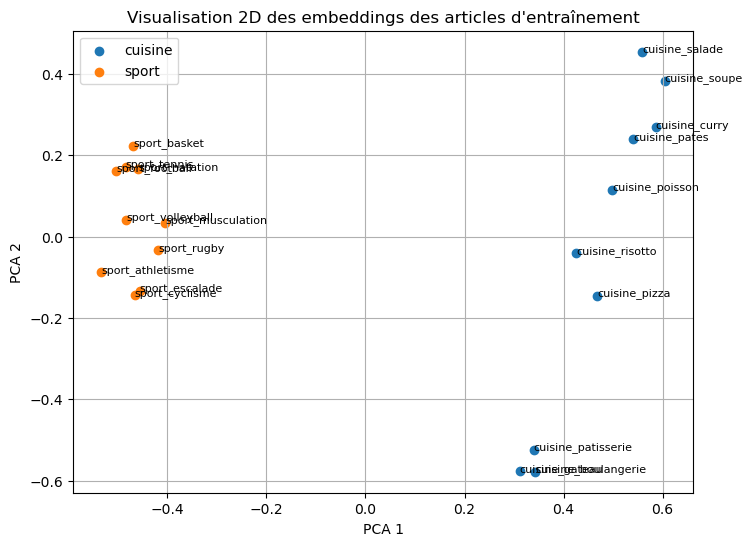

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_train)

viz = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "label": labels_train,
    "fichier": df_train["fichier"],
})

plt.figure(figsize=(8, 6))
for label in viz["label"].unique():
    sous_df = viz[viz["label"] == label]
    plt.scatter(sous_df["x"], sous_df["y"], label=label)
    for _, row in sous_df.iterrows():
        plt.text(row["x"], row["y"], row["fichier"].replace(".docx", ""), fontsize=8)

plt.title("Visualisation 2D des embeddings des articles d'entraînement")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()

### Interprétation du graphique PCA

Le graphique représente les embeddings des articles d’entraînement projetés en deux dimensions avec une PCA.

On observe une séparation assez nette entre les deux catégories. Les articles de **sport** sont regroupés principalement à gauche du graphique, tandis que les articles de **cuisine** sont regroupés à droite. Cela montre que les embeddings capturent bien une différence de contenu entre les textes sportifs et les textes culinaires.

On remarque aussi que les articles de cuisine sont un peu plus dispersés que les articles de sport. Cela peut s’expliquer par la diversité des thèmes culinaires : soupe, pizza, pâtisserie, salade, poisson, etc. Les articles de sport sont ici plus regroupés, ce qui indique qu’ils sont plus proches entre eux dans l’espace vectoriel.

Les articles ambigus n’apparaissent pas dans ce graphique, car la visualisation concerne uniquement les articles d’entraînement. 

### Part de variance expliquée par les composantes PCA

La PCA réduit les embeddings de 384 dimensions vers un nombre plus faible de dimensions.  
Cependant, cette réduction entraîne forcément une perte d’information.

La part de variance expliquée permet de mesurer quelle quantité d’information est conservée par les premières composantes principales.  
Plus cette valeur est élevée, plus la projection garde une part importante de la structure initiale des embeddings.

Cette étape permet donc de mieux comprendre la limite de la visualisation en 2D : le graphique précédent est utile pour observer une tendance générale, mais il ne représente pas toute l’information contenue dans les embeddings originaux.

In [45]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=5)
embeddings_pca = pca.fit_transform(embeddings_train)

variance_expliquee = pca.explained_variance_ratio_

df_variance = pd.DataFrame({
    "composante": ["PCA1", "PCA2", "PCA3", "PCA4", "PCA5"],
    "variance_expliquee": variance_expliquee,
    "variance_expliquee_%": variance_expliquee * 100,
    "variance_cumulee_%": variance_expliquee.cumsum() * 100
})

df_variance

,composante,variance_expliquee,variance_expliquee_%,variance_cumulee_%
0,PCA1,0.326788,32.678814,32.678814
1,PCA2,0.119592,11.959180,44.637993
2,PCA3,0.098326,9.832636,54.470627
3,PCA4,0.056816,5.681623,60.152252
4,PCA5,0.049902,4.990239,65.142487


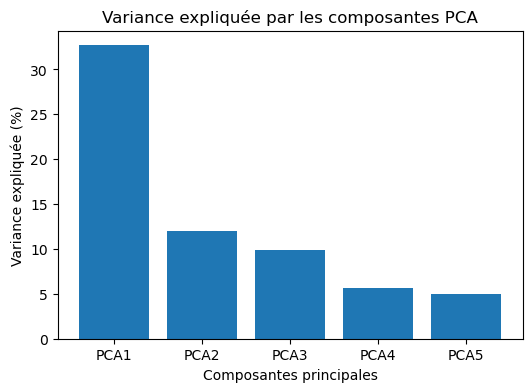

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(df_variance["composante"], df_variance["variance_expliquee_%"])
plt.xlabel("Composantes principales")
plt.ylabel("Variance expliquée (%)")
plt.title("Variance expliquée par les composantes PCA")
plt.show()

### Interprétation de la variance expliquée

La première composante principale explique environ **32,68 %** de la variance des embeddings. Elle représente donc l’axe qui résume le plus d’information parmi les 384 dimensions d’origine.

La deuxième composante explique environ **11,59 %** de variance supplémentaire. Ensemble, les deux premières composantes utilisées pour le graphique 2D expliquent donc environ **44,64 %** de la variance totale.

Cela signifie que la visualisation en deux dimensions conserve une partie importante de l’information, mais pas la totalité. Le graphique PCA est donc utile pour observer une tendance générale, comme la séparation entre les articles de sport et de cuisine, mais il reste une simplification des embeddings d’origine.

Avec les cinq premières composantes, on atteint environ **65,14 %** de variance cumulée. Cela confirme que l’information est répartie sur plusieurs dimensions, ce qui est normal pour des embeddings textuels.

Il faut donc bien distinguer deux choses : la PCA sert uniquement à visualiser les embeddings, tandis que la recherche FAISS et la classification utilisent les vecteurs complets de **384 dimensions**.

### Variance cumulée

La variance cumulée permet de voir combien d’information est conservée lorsqu’on additionne progressivement les composantes principales. Elle aide à comprendre jusqu’où la représentation PCA résume les embeddings d’origine.

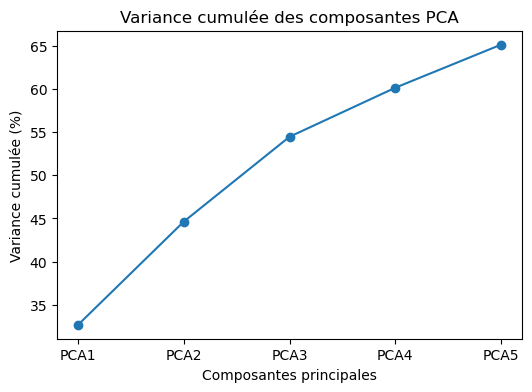

In [47]:
plt.figure(figsize=(6, 4))
plt.plot(df_variance["composante"], df_variance["variance_cumulee_%"], marker="o")
plt.xlabel("Composantes principales")
plt.ylabel("Variance cumulée (%)")
plt.title("Variance cumulée des composantes PCA")
plt.show()

### Interprétation de la variance cumulée

Ce graphique montre la variance cumulée expliquée par les premières composantes PCA.

La première composante explique environ **32,68 %** de la variance. En ajoutant la deuxième composante, on atteint environ **44,64 %**. Cela correspond à la quantité d’information conservée dans le graphique PCA en deux dimensions.

En ajoutant les composantes suivantes, la variance cumulée augmente progressivement : environ **54,47 %** avec trois composantes, **60,15 %** avec quatre composantes et **65,14 %** avec cinq composantes.

Cela montre que les deux premières composantes permettent déjà de visualiser une partie importante de la structure des embeddings, mais qu’une partie de l’information reste répartie dans d’autres dimensions. C’est normal, car les embeddings d’origine comportent **384 dimensions**.


## 13. Conclusion

Ce notebook répond à l’objectif du travail : lire des articles au format Word (`.docx`) et déterminer s’ils correspondent principalement à des articles de sport ou de cuisine. Pour cela, les textes sont d’abord nettoyés et tokenisés en ignorant la ponctuation, puis transformés en embeddings à l’aide d’un modèle de phrases. Ces embeddings permettent de représenter chaque article sous forme de vecteur numérique et de comparer les textes selon leur sens général.

La base vectorielle FAISS est utilisée pour stocker les embeddings des articles d’entraînement et rechercher, pour chaque nouvel article, les documents les plus proches. La prédiction est ensuite réalisée à partir des voisins les plus similaires. Cette approche permet donc de ne pas se limiter à une simple recherche de mots-clés, mais de tenir compte de la proximité de sens entre les textes.

Les résultats obtenus sur les fichiers de test sont satisfaisants. Les articles clairement liés au sport ou à la cuisine sont correctement classés, et les textes volontairement ambigus sont détectés comme tels grâce à la règle de confiance ajoutée. Cette règle évite de forcer une classification lorsque les voisins sont trop partagés ou lorsque la similarité avec les documents d’entraînement est trop faible.

La visualisation des embeddings avec la PCA permet aussi d’observer que les articles d’une même catégorie ont tendance à se rapprocher dans l’espace vectoriel. Elle reste toutefois indicative, car les embeddings originaux sont réduits en deux dimensions.

La méthode reste enfin dépendante de la qualité et de la diversité des textes d’entraînement. Les résultats sont bons dans le cadre de ce travail, mais ils sont obtenus sur un nombre limité d’articles. Pour améliorer la robustesse du programme, il serait utile de tester davantage d’articles réels, plus longs et plus variés.